# SPOT 6/7 Data Search & Download

Search and download SPOT 6/7 imagery from the French national STAC catalog  
[api.stac.teledetection.fr](https://api.stac.teledetection.fr) — DINAMIS program.

**Coverage:** metropolitan France (41–51°N, 5.5°W–9.7°E)  
**Period:** 2017-04 → 2023-10  
**Products:**
- `src_xs` — multispectral COG, 6 m, 4 bands (R, G, B, NIR)
- `src_pan` — panchromatic COG, 1.5 m
- `dimap_xs`, `dimap_pan` — XML metadata (acquisition date, orbit, processing info)
- `cld_msk_vec_xs`, `cld_msk_vec_pan` — cloud masks (GeoPackage)
- `rendered_preview` — PNG quicklook

**Requirements (install once into your env):**
```bash
pip install pystac-client python-dotenv
```

**Setup:** API keys (`access-key` / `secret-key`) must be in a `.env` file at the project root (not committed to git).

## 1. Imports & Authentication

In [9]:
import os
import geopandas as gpd
import pandas as pd
import requests
import rasterio
from rasterio.mask import mask as rio_mask
from pathlib import Path
from shapely.geometry import shape
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt

from dotenv import load_dotenv
import teledetection as tld
import pystac_client

In [2]:
load_dotenv()

# The SDK uses your OS keychain/credentials automatically
# On first run, it opens a browser to log you in via Keycloak
api = pystac_client.Client.open(
    "https://api.stac.teledetection.fr",
    modifier=tld.sign_inplace,  # ← this signs URLs automatically
)
print(f"✓ Connected to: {api.title}")

✓ Connected to: MTD STAC API


In [3]:
# Load keys from .env file in project root
load_dotenv()

HEADERS = {
    "access-key": os.environ.get("MDT_SPOT67_STAC_ACCESS_KEY"),
    "secret-key":  os.environ.get("MDT_SPOT67_STAC_SECRET_KEY"),
}

# Validate that keys are present
if not HEADERS["access-key"] or not HEADERS["secret-key"]:
    raise RuntimeError(
        "STAC_ACCESS_KEY or STAC_SECRET_KEY not found in .env file.\n"
        "Please ensure .env exists in the project root with these variables."
    )

print("✓ Loaded API keys from .env")

# Connect to STAC catalog
api = pystac_client.Client.open(
    "https://api.stac.teledetection.fr",
    headers=HEADERS,
)
print(f"✓ Connected to: {api.title}")

✓ Loaded API keys from .env
✓ Connected to: MTD STAC API


## 2. Explore Collections

The catalog has ~39 collections. The one with raw SPOT 6/7 scenes is **`spot-6-7-drs`**.

In [4]:
# List all SPOT-related collections
spot_collections = [
    c
    for c in api.get_collections()
    if "spot" in c.id.lower() or "spot" in c.title.lower()
]
for c in spot_collections:
    print(f"{c.id:45s}  {c.title}")

FORMSpoT                                       FORMSpoT
FORMSpoT-delta                                 FORMSpoT-∆
spot-6-7-buildings-footprint                   Spot 6/7 buildings footprint
spot-6-7-drs                                   Spot-6/7 DINAMIS products
spot-6-7-footprints                            Spot 6/7 6-classes footprints
spot-6-7-solar-panels                          Solar panels mapping from Spot-6/7 imagery
spot-6-7-solar-panels-v2                       Solar panels mapping from Spot-6/7 imagery (v2)
spot-6-7-trees-footprint                       Spot 6/7 trees footprint
super-sentinel-2-l2a                           Synthetic Sentinel-2 L2A (R, G, B, NIR) fused with Spot-6/7


In [5]:
# Inspect the main raw-imagery collection
col = api.get_collection("spot-6-7-drs")
print(col.title)
print(col.description)
print("Temporal extent:", col.extent.temporal.intervals)

Spot-6/7 DINAMIS products
Produits Spot-6 et Spot-7 acquis dans le cadre de Dinamis par la station de reception de Montpellier.
Temporal extent: [[datetime.datetime(2017, 4, 4, 10, 21, 1, 458000, tzinfo=tzutc()), datetime.datetime(2023, 10, 10, 10, 15, 25, 557000, tzinfo=tzutc())]]


## 3. Define AOI

Choose **one** of the options below.  
The bbox must be in WGS84 `[west, south, east, north]` (longitude / latitude).

## 3a. Loading `AOI` from existing `Shapefile` or `GeoPackage`

In [6]:
# --- Option A: load from a GeoPackage / Shapefile ---
aoi_path = "/home/cusicand/05_Devs/GeoMultiCorr/geomulticorr/resources/AOI_DataDownload_SPOT67_FrenchAlps.gpkg"
aoi_gdf = gpd.read_file(aoi_path).to_crs(epsg=4326)
bbox = list(aoi_gdf.total_bounds)  # [minx, miny, maxx, maxy]

In [ ]:
# --- Option B: draw a manual bounding box ---
# [west, south, east, north] in decimal degrees WGS84
bbox = [5.5, 45.0, 7.0, 46.5]   # French Alps example
aoi_gdf = None                    # set to None when using manual bbox

In [6]:
print(f"Bounding box: {bbox}")

Bounding box: [np.float64(6.56839756281293), np.float64(45.32260022859949), np.float64(6.6191041944418405), np.float64(45.355360520030295)]


## 4. Search

In [7]:
DATE_START = "2017-01-01"
DATE_END   = "2017-12-31"   # collection ends 2023-10

search = api.search(
    collections=["spot-6-7-drs"],
    bbox=bbox,
    datetime=f"{DATE_START}/{DATE_END}",
    limit=100,
)

# Fetch all pages as raw dicts (asset hrefs are plain MinIO URLs — no signing needed)
items = list(search.items_as_dicts())
print(f"Found {len(items)} scenes")

Found 31 scenes


In [8]:
# Build a summary GeoDataFrame
rows = []
for it in items:
    props = it["properties"]
    rows.append({
        "id":          it["id"],
        "datetime":    pd.to_datetime(props.get("datetime")),
        "platform":    props.get("platform"),
        "cloud_cover": props.get("eo:cloud_cover"),
        "geometry":    shape(it["geometry"]),
        "assets":      list(it["assets"].keys()),
    })

gdf = gpd.GeoDataFrame(rows, geometry="geometry", crs="EPSG:4326")
gdf = gdf.sort_values("datetime").reset_index(drop=True)
gdf[["id", "datetime", "platform", "cloud_cover", "assets"]]

,id,datetime,platform,cloud_cover,assets
0,SPOT6_MS_201704061004577_SPOT6_P_201704061004577,2017-04-06 10:05:05.599000+00:00,spot-6,None,"[src_xs, src_pan, dimap_xs, dimap_pan, cld_msk..."
1,SPOT6_MS_201704061005576_SPOT6_P_2017040610055...,2017-04-06 10:05:58.087000+00:00,spot-6,None,"[src_xs, src_pan, dimap_xs, dimap_pan, cld_msk..."
2,SPOT7_MS_201704121010160_SPOT7_P_2017041210101...,2017-04-12 10:10:24.206000+00:00,spot-7,None,"[src_xs, src_pan, dimap_xs, dimap_pan, cld_msk..."
3,SPOT7_MS_201704121010160_SPOT7_P_2017041210101...,2017-04-12 10:10:32.094000+00:00,spot-7,None,"[src_xs, src_pan, dimap_xs, dimap_pan, cld_msk..."
4,SPOT6_MS_201704131002119_SPOT6_P_201704131002119,2017-04-13 10:02:12.235000+00:00,spot-6,None,"[src_xs, src_pan, dimap_xs, dimap_pan, cld_msk..."
5,SPOT6_MS_201705091002389_SPOT6_P_201705091002389,2017-05-09 10:02:46.565000+00:00,spot-6,None,"[src_xs, src_pan, dimap_xs, dimap_pan, cld_msk..."
6,SPOT7_MS_201705151006147_SPOT7_P_201705151006147,2017-05-15 10:06:14.918000+00:00,spot-7,None,"[src_xs, src_pan, dimap_xs, dimap_pan, cld_msk..."
7,SPOT7_MS_201705221001290_SPOT7_P_201705221001290,2017-05-22 10:01:29.016000+00:00,spot-7,None,"[src_xs, src_pan, dimap_xs, dimap_pan, cld_msk..."
8,SPOT7_MS_201705221001432_SPOT7_P_201705221001432,2017-05-22 10:01:43.612000+00:00,spot-7,None,"[src_xs, src_pan, dimap_xs, dimap_pan, cld_msk..."
9,SPOT7_MS_201705271013180_SPOT7_P_2017052710131...,2017-05-27 10:13:18.263000+00:00,spot-7,None,"[src_xs, src_pan, dimap_xs, dimap_pan, cld_msk..."


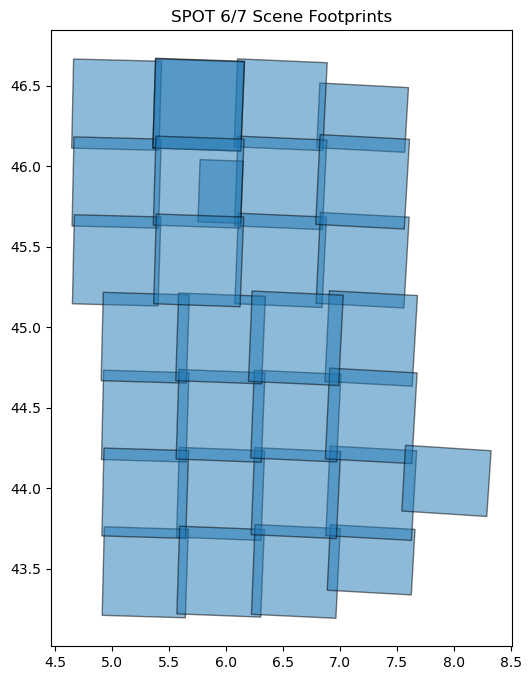

In [10]:
# Simple plot
ax = gdf.plot(figsize=(10, 8), alpha=0.5, edgecolor='black')
ax.set_title('SPOT 6/7 Scene Footprints')
plt.show()
# Or with more detail:

/tmp/ipykernel_223701/2221982306.py:14: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
/tmp/ipykernel_223701/2221982306.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


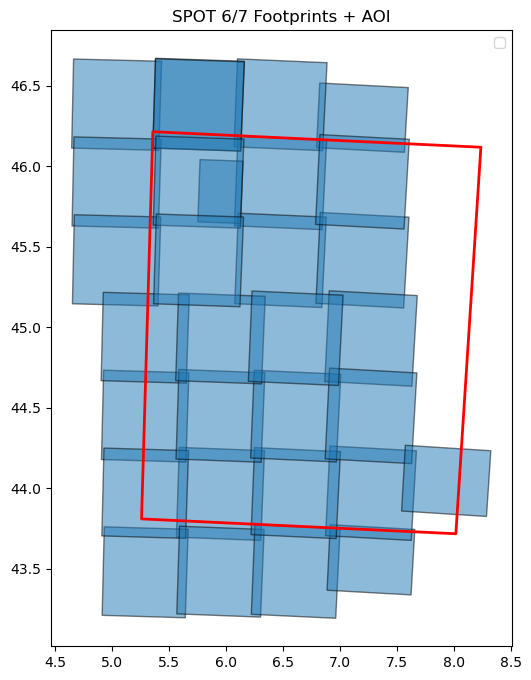

In [13]:
# Plot with cloud cover as color
ax = gdf.plot(
    legend=True,
    alpha=0.5,
    edgecolor='black',
    figsize=(10, 8)
)

# Overlay your AOI
if aoi_gdf is not None:
    aoi_gdf.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2, label='AOI')

plt.title('SPOT 6/7 Footprints + AOI')
plt.legend()
plt.show()

## 5. Inspect & Filter

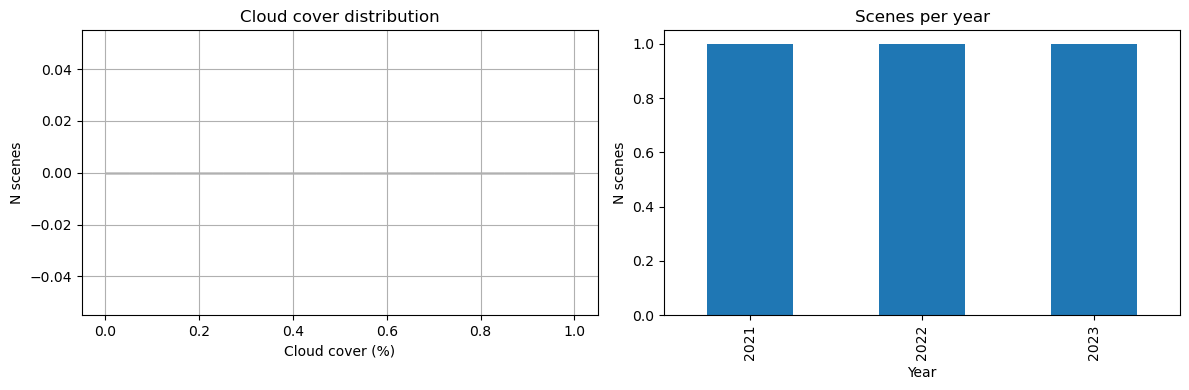

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Cloud cover distribution
gdf["cloud_cover"].hist(bins=20, ax=axes[0], edgecolor="black")
axes[0].set_xlabel("Cloud cover (%)")
axes[0].set_ylabel("N scenes")
axes[0].set_title("Cloud cover distribution")

# Scenes per year
gdf["year"] = gdf["datetime"].dt.year
gdf["year"].value_counts().sort_index().plot(kind="bar", ax=axes[1])
axes[1].set_xlabel("Year")
axes[1].set_ylabel("N scenes")
axes[1].set_title("Scenes per year")

plt.tight_layout()
plt.show()

In [18]:
# Filter by cloud cover threshold
CLOUD_MAX = 20   # percent

gdf_clean = gdf[gdf["cloud_cover"] <= CLOUD_MAX].copy().reset_index(drop=True)
print(f"{len(gdf_clean)} / {len(gdf)} scenes pass the {CLOUD_MAX}% cloud filter")
gdf_clean[["id", "datetime", "platform", "cloud_cover"]]

0 / 3 scenes pass the 20% cloud filter


,id,datetime,platform,cloud_cover


ValueError: aspect must be finite and positive 

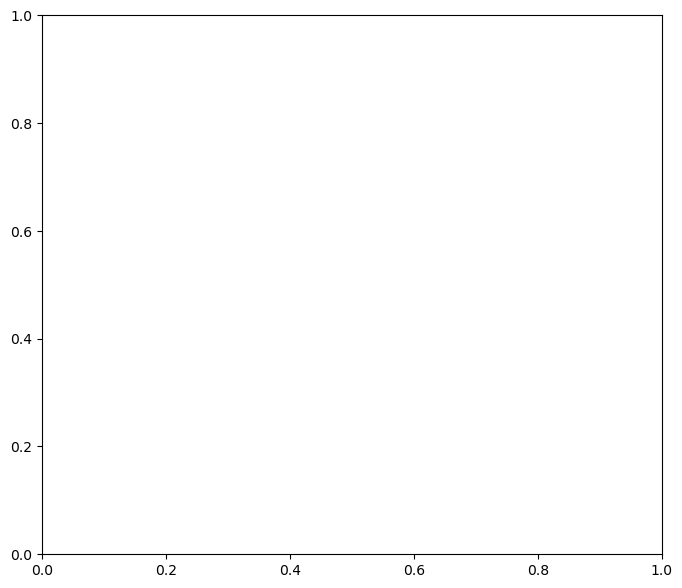

In [14]:
# Plot scene footprints
ax = gdf_clean.plot(
    column="cloud_cover",
    cmap="RdYlGn_r",
    legend=True,
    alpha=0.5,
    edgecolor="black",
    linewidth=0.5,
    figsize=(8, 7),
)
ax.set_title(f"SPOT 6/7 footprints — {DATE_START} / {DATE_END} (cloud ≤ {CLOUD_MAX}%)")
plt.show()

## 6. Download (full scenes + metadata)

Assets are Cloud-Optimized GeoTIFFs (COGs) + XML metadata on MinIO object storage.  
The same `HEADERS` dict used for search is passed to every `requests.get` call — no URL signing needed.

In [16]:
OUTPUT_DIR   = Path("/media/cusicand/LaCie/SPOT_FR/TEST/")
# ASSETS       = ["src_xs", "src_pan"]   # multispectral (6 m) + panchromatic (1.5 m)
ASSETS       = ["src_pan"]
MAX_DOWNLOAD = None                     # set to an integer to cap downloads during testing

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ids_to_download = set(gdf["id"])
if MAX_DOWNLOAD:
    ids_to_download = set(list(ids_to_download)[:MAX_DOWNLOAD])

# Reuse the already-fetched raw-dict items — no re-search needed
selected_items = [it for it in items if it["id"] in ids_to_download]

downloaded = []
for it in tqdm(selected_items, desc="Scenes", unit="scene"):
    date_str = pd.to_datetime(it["properties"]["datetime"]).strftime("%Y%m%d")
    for asset_key in ASSETS:
        asset_href = it["assets"].get(asset_key, {}).get("href")
        url = asset_href
        if not asset_href:
            continue
        print(it['id'])
        print(asset_key)
        print(date_str)
        new_filename = f"{it['id']}_{asset_key}_{date_str}.tif"
        out_path = OUTPUT_DIR / new_filename
        print(out_path)
        # if out_path.exists():
        #     print(f"  skip (exists): {out_path.name}")
        #     downloaded.append(out_path)
        #     continue
        # with requests.get(url, stream=True, timeout=300) as r:
        #     r.raise_for_status()
        #     total_mb = int(r.headers.get("content-length", 0)) / 1e6
        #     with open(out_path, "wb") as f:
        #         for chunk in tqdm(
        #             r.iter_content(chunk_size=1 << 20),
        #             desc=f"  {asset_key}",
        #             total=int(total_mb) or None,
        #             unit="MB",
        #             leave=False,
        #         ):
        #             f.write(chunk)
        # size_mb = out_path.stat().st_size / 1e6
        # print(f"  ✓ {out_path.name}  ({size_mb:.1f} MB)")
        # downloaded.append(out_path)

print(f"\nDone — {len(downloaded)} files in {OUTPUT_DIR}")

Scenes:   0%|          | 0/3 [00:00<?, ?scene/s]

SPOT6_MS_202309091003359_SPOT6_P_202309091003359_0
src_pan
20230909
/media/cusicand/LaCie/SPOT_FR/TEST/SPOT6_MS_202309091003359_SPOT6_P_202309091003359_0_src_pan_20230909.tif
SPOT7_MS_202206111003127_SPOT7_P_202206111003127_0
src_pan
20220611
/media/cusicand/LaCie/SPOT_FR/TEST/SPOT7_MS_202206111003127_SPOT7_P_202206111003127_0_src_pan_20220611.tif
SPOT6_MS_202109231011351_SPOT6_P_202109231011351_0
src_pan
20210923
/media/cusicand/LaCie/SPOT_FR/TEST/SPOT6_MS_202109231011351_SPOT6_P_202109231011351_0_src_pan_20210923.tif

Done — 0 files in /media/cusicand/LaCie/SPOT_FR/TEST


In [ ]:
# ============================================================================
# Section 6b: Download Panchromatic + Metadata with CLEAN NAMING
# ============================================================================

def generate_clean_filename(item_dict, asset_key, extension):
    """
    Generate clean filename: IMG_SPOT6_P_YYYYMMDD.tif or IMG_SPOT6_P_YYYYMMDD_metadata.xml
    Adds _P_ suffix for panchromatic, _MS_ for multispectral
    """
    platform = item_dict["properties"].get("platform", "unknown").upper()
    platform_num = platform.split("-")[-1]  # "spot-6" → "6"
    date_str = pd.to_datetime(item_dict["properties"]["datetime"]).strftime("%Y%m%d")
    
    # Determine sensor type
    if asset_key in ["src_pan", "dimap_pan"]:
        sensor_type = "P"
    elif asset_key in ["src_xs", "dimap_xs"]:
        sensor_type = "MS"
    else:
        sensor_type = "_"
    
    # Generate filename
    if asset_key == "src_pan":
        return f"IMG_SPOT{platform_num}_{sensor_type}_{date_str}.{extension}"
    elif asset_key == "dimap_pan":
        return f"IMG_SPOT{platform_num}_{sensor_type}_{date_str}_metadata.{extension}"
    else:
        return f"IMG_SPOT{platform_num}_{sensor_type}_{date_str}_{asset_key}.{extension}"

# Download directory
PAN_OUTPUT_DIR = Path("/media/cusicand/LaCie/SPOT_FR/Panchromatic_Clean")
PAN_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Assets to download as a pair
PAN_ASSETS = ["src_pan", "dimap_pan"]

pan_downloaded = []
for it in tqdm(selected_items, desc="Pan + Metadata", unit="scene"):
    date_str = pd.to_datetime(it["properties"]["datetime"]).strftime("%Y%m%d")
    
    # Download both image and metadata for this scene
    for asset_key in PAN_ASSETS:
        asset_href = it["assets"].get(asset_key, {}).get("href")
        if not asset_href:
            continue
        
        # Generate clean filename
        ext = "tif" if asset_key == "src_pan" else "xml"
        clean_filename = generate_clean_filename(it, asset_key, ext)
        out_path = PAN_OUTPUT_DIR / clean_filename
        
        # Skip if already downloaded
        if out_path.exists():
            print(f"  skip (exists): {clean_filename}")
            pan_downloaded.append(out_path)
            continue
        
        # Download
        print(f"  downloading: {clean_filename}...", end="")
        try:
            with requests.get(asset_href, headers=HEADERS, stream=True, timeout=300) as r:
                r.raise_for_status()
                with open(out_path, "wb") as f:
                    for chunk in r.iter_content(chunk_size=1 << 20):
                        f.write(chunk)
            size_mb = out_path.stat().st_size / 1e6
            print(f" ✓ ({size_mb:.1f} MB)")
            pan_downloaded.append(out_path)
        except Exception as e:
            print(f" ✗ {type(e).__name__}")
            if out_path.exists():
                out_path.unlink()

print(f"\n✓ Downloaded {len(pan_downloaded)} files")
print(f"\nFiles:")
for p in sorted(pan_downloaded):
    print(f"  {p.name}")

## 7. Extract info from DIMAP XML

Parse DIMAP XML metadata to extract acquisition date, orbit info, processing details.

In [ ]:
import xml.etree.ElementTree as ET

# Find one DIMAP file to inspect
dimap_files = list(METADATA_DIR.glob("*_dimap_xs_*.xml"))
if dimap_files:
    xml_path = dimap_files[0]
    print(f"Sample DIMAP file: {xml_path.name}\n")
    tree = ET.parse(xml_path)
    root = tree.getroot()
    print(ET.tostring(root, encoding='unicode')[:2000])  # first 2000 chars

In [ ]:
# Extract key metadata from all DIMAP files
import re

metadata_table = []
for xml_path in METADATA_DIR.glob("*_dimap_xs_*.xml"):
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
        
        # Define namespace (most SPOT DIMAP files use a namespace)
        ns = {'root': 'http://www.spotimage.fr/dimap/2.4'}
        
        # Try with namespace first, fallback to no namespace
        imaging_date = root.findtext('.//root:IMAGING_DATE', namespaces=ns)
        imaging_time = root.findtext('.//root:IMAGING_TIME', namespaces=ns)
        instrument = root.findtext('.//root:INSTRUMENT', namespaces=ns)
        orbit_number = root.findtext('.//root:ORBIT_NUMBER', namespaces=ns)
        
        # Fallback to non-namespaced search if needed
        if not imaging_date:
            imaging_date = root.findtext('.//IMAGING_DATE')
        if not imaging_time:
            imaging_time = root.findtext('.//IMAGING_TIME')
        if not instrument:
            instrument = root.findtext('.//INSTRUMENT')
        if not orbit_number:
            orbit_number = root.findtext('.//ORBIT_NUMBER')
        
        metadata_table.append({
            "scene_id": xml_path.stem.split('_')[0],
            "acquisition_date": imaging_date,
            "acquisition_time": imaging_time,
            "instrument": instrument,
            "orbit": orbit_number,
            "xml_file": xml_path.name,
        })
    except Exception as e:
        print(f"  Error parsing {xml_path.name}: {e}")

metadata_df = pd.DataFrame(metadata_table)
print(f"\nExtracted metadata from {len(metadata_df)} scenes:")
print(metadata_df[['scene_id', 'acquisition_date', 'acquisition_time', 'instrument', 'orbit']])

## 8. Alternative: COG Clip (AOI window only — no full-scene download)

Because assets are COGs, GDAL/rasterio can request only the tiles that overlap your AOI  
— avoids downloading the full 400–800 MB scene.  
Requires a polygon `aoi_gdf` defined in Section 3.

Auth headers are passed to GDAL's HTTP layer via `rasterio.Env`.

In [ ]:
if aoi_gdf is None:
    raise RuntimeError("aoi_gdf is None — load a polygon AOI in Section 3 to use COG clipping.")

COG_OUTPUT_DIR = Path("/home/cusicand/03_Data/GMC_REPOSITORY/SPOT_6_7_clips")
COG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

aoi_geom = list(aoi_gdf.geometry)

# Build GDAL header string: "Key1: value1\r\nKey2: value2"
gdal_headers = "\r\n".join(f"{k}: {v}" for k, v in HEADERS.items())

for it in tqdm(selected_items, desc="COG clips", unit="scene"):
    date_str = pd.to_datetime(it["properties"]["datetime"]).strftime("%Y%m%d")
    for asset_key in ["src_xs"]:   # MS only — Pan clips are still large
        asset_href = it["assets"].get(asset_key, {}).get("href")
        if not asset_href:
            continue
        out_path = COG_OUTPUT_DIR / f"{it['id']}_{asset_key}_{date_str}_clip.tif"
        if out_path.exists():
            continue
        with rasterio.Env(GDAL_HTTP_HEADERS=gdal_headers):
            with rasterio.open(asset_href) as src:
                clipped, transform = rio_mask(src, aoi_geom, crop=True)
                profile = src.profile.copy()
                profile.update({
                    "height":    clipped.shape[1],
                    "width":     clipped.shape[2],
                    "transform": transform,
                    "driver":    "GTiff",
                })
                with rasterio.open(out_path, "w", **profile) as dst:
                    dst.write(clipped)
        print(f"  ✓ {out_path.name}  ({out_path.stat().st_size / 1e6:.1f} MB)")